In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url_drive = 'https://drive.google.com/file/d/1zMWmL7A-VH3_wPYgCiUH6bMbd39EPrcQ/view?usp=sharing'

file_id = url_drive.split('/d/')[1].split('/')[0]

url_descarga = f'https://drive.google.com/uc?export=download&id={file_id}'

try:
    df = pd.read_csv(url_descarga)
    print("¡Base de datos cargada correctamente!")
    print(f"Total de registros: {len(df)}")
    display(df.head())
except Exception as e:
    print(f"Error al cargar la base: {e}")

¡Base de datos cargada correctamente!
Total de registros: 30000


,texto_completo,categoria
0,React 18: Hydration failed because the initial...,Frontend
1,Why does Visual Studio Code give me an error w...,Frontend
2,"""A listener indicated an asynchronous response...",Frontend
3,Deprecation notice: ReactDOM.render is no long...,Frontend
4,"Message ""npm WARN config global `--global`, `-...",Frontend


In [3]:
df.head()

,texto_completo,categoria
0,React 18: Hydration failed because the initial...,Frontend
1,Why does Visual Studio Code give me an error w...,Frontend
2,"""A listener indicated an asynchronous response...",Frontend
3,Deprecation notice: ReactDOM.render is no long...,Frontend
4,"Message ""npm WARN config global `--global`, `-...",Frontend


In [4]:
print("--- Valores Nulos ---")
print(df.isnull().sum())

print("\n--- Duplicados ---")
print(f"Registros duplicados: {df.duplicated().sum()}")

--- Valores Nulos ---
texto_completo    0
categoria         0
dtype: int64

--- Duplicados ---
Registros duplicados: 0


In [5]:
# RESUMEN DE NULOS Y DUPLICADOS
print("Control de calidad y duplicados")
print(f"Total de registros: {len(df)}")
print(f"Valores nulos por columna:\n{df.isnull().sum()}\n")

duplicados = df['texto_completo'].duplicated().sum()
print(f"Textos duplicados detectados: {duplicados} ({duplicados/len(df)*100:.2f}%)")

Control de calidad y duplicados
Total de registros: 30000
Valores nulos por columna:
texto_completo    0
categoria         0
dtype: int64

Textos duplicados detectados: 1319 (4.40%)


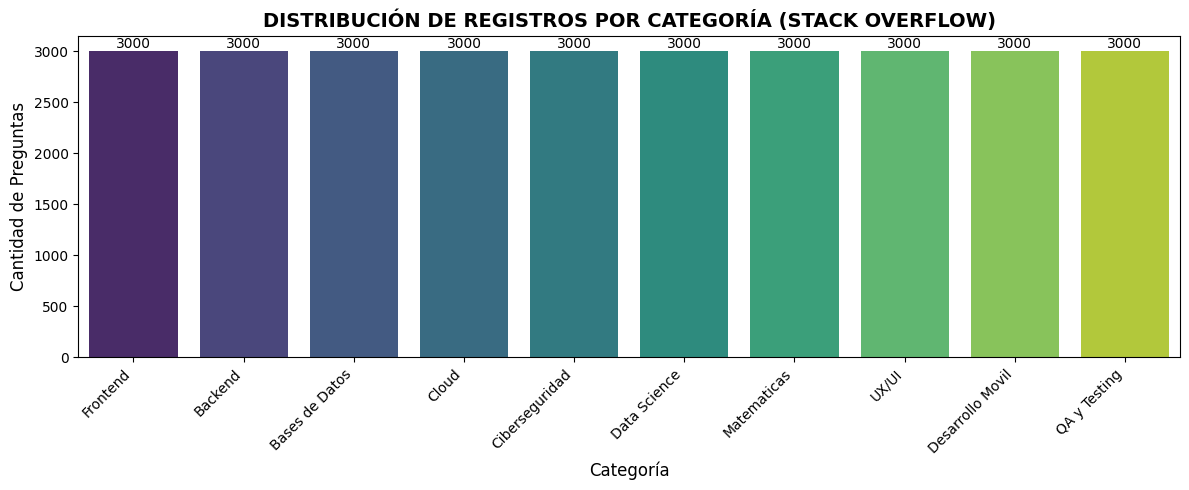

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

ax = sns.countplot(
    data=df,
    x='categoria',
    hue='categoria',
    palette='viridis',
    legend=False,
    order=df['categoria'].value_counts().index
)

plt.title('DISTRIBUCIÓN DE REGISTROS POR CATEGORÍA (STACK OVERFLOW)', fontsize=14, fontweight='bold')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Cantidad de Preguntas', fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

--- ESTADÍSTICAS DE LONGITUD DE TEXTO ---
count    30000.000000
mean       216.354133
std        211.309023
min         11.000000
25%        101.000000
50%        160.000000
75%        258.000000
max       4133.000000
Name: contador_palabras, dtype: float64

Textos extremadamente cortos (<15 palabras): 3
Textos extremadamente largos (>800 palabras): 600


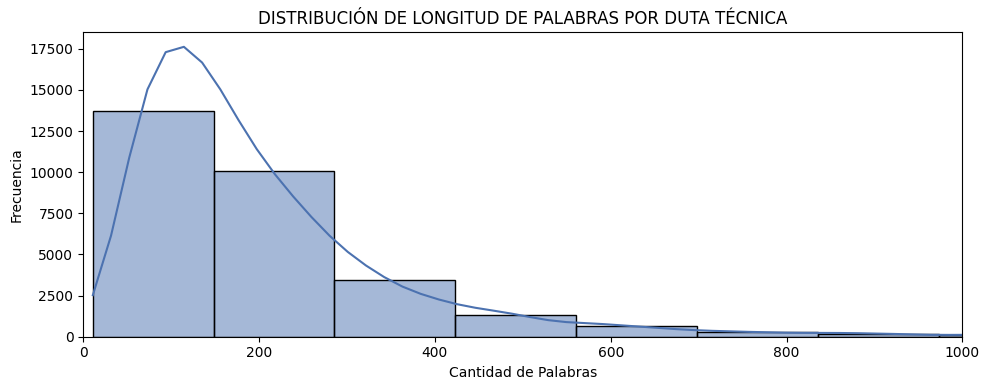

In [7]:
# CALCULAR LONGITUD EN PALABRAS
df['contador_palabras'] = df['texto_completo'].apply(lambda x: len(str(x).split()))

# ESTADÍSTICAS DESCRIPTIVAS
print("--- ESTADÍSTICAS DE LONGITUD DE TEXTO ---")
print(df['contador_palabras'].describe())

# IDENTIFICAR TEXTOS ATIPICOS (OUTLIERS)
cortos = (df['contador_palabras'] < 15).sum()
largos = (df['contador_palabras'] > 800).sum()
print(f"\nTextos extremadamente cortos (<15 palabras): {cortos}")
print(f"Textos extremadamente largos (>800 palabras): {largos}")

# GRÁFICA DE DISTRIBUCIÓN DE PALABRAS
plt.figure(figsize=(10, 4))
sns.histplot(df['contador_palabras'], bins=30, kde=True, color='#4C72B0')
plt.title('DISTRIBUCIÓN DE LONGITUD DE PALABRAS POR DUTA TÉCNICA', fontsize=12)
plt.xlabel('Cantidad de Palabras')
plt.ylabel('Frecuencia')
plt.xlim(0, 1000) # SE CORTA EN 1000 PARA APRECIAR MEJOR LA MASA PRINCIPAL
plt.tight_layout()
plt.show()

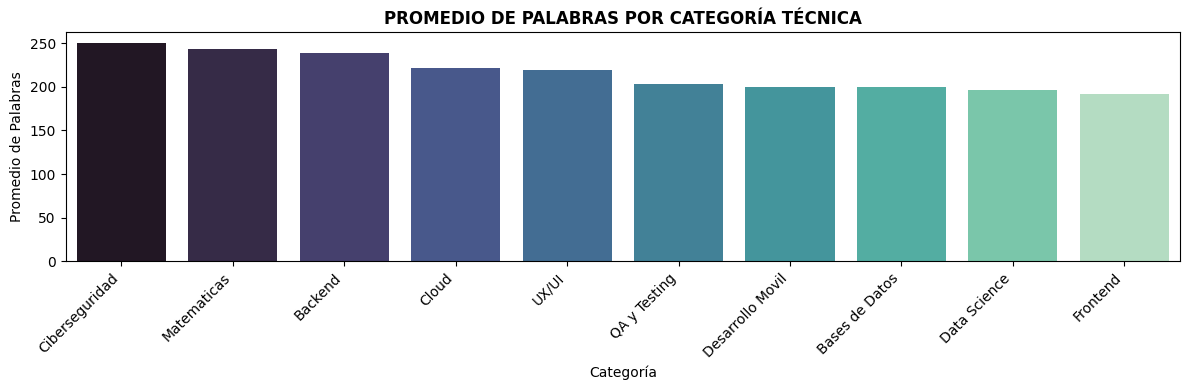

In [8]:
plt.figure(figsize=(12, 4))
promedios = df.groupby('categoria')['contador_palabras'].mean().sort_values(ascending=False)

sns.barplot(
    x=promedios.index,
    y=promedios.values,
    hue=promedios.index,
    palette='mako',
    legend=False
)

plt.title('PROMEDIO DE PALABRAS POR CATEGORÍA TÉCNICA', fontsize=12, fontweight='bold')
plt.xlabel('Categoría')
plt.ylabel('Promedio de Palabras')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()